In [10]:
import os

os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

from pathlib import Path
import cv2
from PIL import Image
from IPython.display import display, clear_output
from ultralytics import YOLO


# Model path
MODEL_PATH = "saved_models/helmet_model.pt"

# Video path
VIDEO_PATH = "v1.mp4"


# Check model
if not Path(MODEL_PATH).exists():
    raise FileNotFoundError(
        f"Model not found: {Path(MODEL_PATH).resolve()}"
    )


# Load model
model = YOLO(MODEL_PATH)

print("Model loaded successfully!")
print("Model path:", Path(MODEL_PATH).resolve())
print("Classes:", model.names)

Model loaded successfully!
Model path: C:\My Space\Github_Repo\Traffic Violation Detection-Deep Learning\saved_models\helmet_model.pt
Classes: {0: 'helmet', 1: 'no helmet'}


       ⚠️ NO HELMET DETECTED
Frame Number : 170
Confidence   : 97.83%
No-Helmet Detections : 44


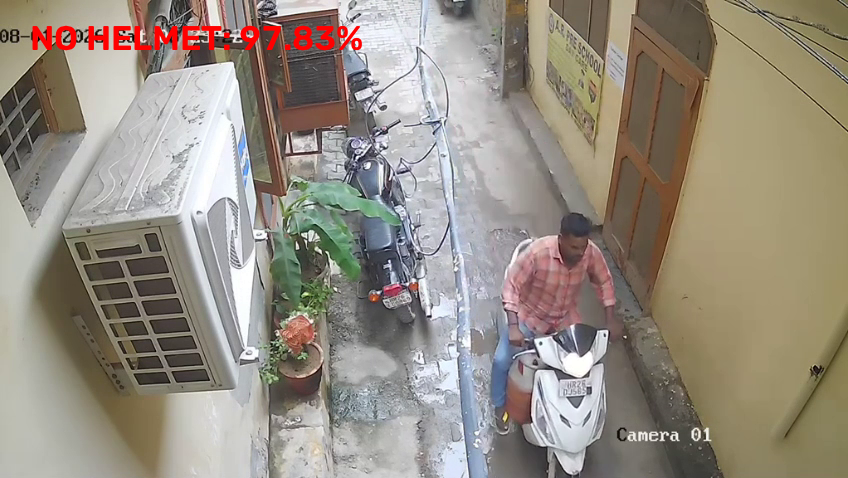


VIDEO TESTING COMPLETED
Total Video Frames : 171
Frames Processed   : 85
No-Helmet Detected : 44
Processing FPS     : 10


In [11]:
# -----------------------------------
# Open video
# -----------------------------------

cap = cv2.VideoCapture(VIDEO_PATH)

if not cap.isOpened():
    raise RuntimeError("Could not open video.")


# -----------------------------------
# Video information
# -----------------------------------

original_fps = cap.get(cv2.CAP_PROP_FPS)

if original_fps <= 0:
    original_fps = 25

total_frames = int(
    cap.get(cv2.CAP_PROP_FRAME_COUNT)
)

width = int(
    cap.get(cv2.CAP_PROP_FRAME_WIDTH)
)

height = int(
    cap.get(cv2.CAP_PROP_FRAME_HEIGHT)
)


# -----------------------------------
# Processing FPS
# -----------------------------------

TARGET_FPS = 10

frame_skip = max(
    1,
    int(original_fps / TARGET_FPS)
)


print("===================================")
print("VIDEO INFORMATION")
print("===================================")
print("Original FPS    :", original_fps)
print("Processing FPS  :", TARGET_FPS)
print("Total Frames    :", total_frames)
print("Resolution      :", width, "x", height)
print("===================================")


# -----------------------------------
# Counters
# -----------------------------------

frame_number = 0
processed_frames = 0
no_helmet_count = 0


# -----------------------------------
# Process video
# -----------------------------------

while True:

    ret, frame = cap.read()

    if not ret:
        break

    frame_number += 1


    # --------------------------------
    # Skip frames
    # --------------------------------

    if frame_number % frame_skip != 0:
        continue

    processed_frames += 1


    # --------------------------------
    # YOLO prediction
    # --------------------------------

    results = model.predict(
        source=frame,
        device="cpu",
        imgsz=640,
        verbose=False
    )

    result = results[0]


    # --------------------------------
    # Get prediction
    # --------------------------------

    class_id = int(
        result.probs.top1
    )

    confidence = float(
        result.probs.top1conf
    )

    predicted_class = result.names[class_id]


    # --------------------------------
    # Check NO HELMET
    # --------------------------------

    normalized_class = (
        predicted_class
        .lower()
        .replace(" ", "_")
    )


    if normalized_class == "no_helmet":

        no_helmet_count += 1


        # Add text to displayed frame
        text = (
            f"NO HELMET: "
            f"{confidence:.2%}"
        )

        cv2.putText(
            frame,
            text,
            (30, 50),
            cv2.FONT_HERSHEY_SIMPLEX,
            1.2,
            (0, 0, 255),
            3
        )


        # Convert BGR → RGB
        frame_rgb = cv2.cvtColor(
            frame,
            cv2.COLOR_BGR2RGB
        )

        image = Image.fromarray(
            frame_rgb
        )


        # --------------------------------
        # Display only no-helmet frame
        # --------------------------------

        clear_output(wait=True)

        print("===================================")
        print("       ⚠️ NO HELMET DETECTED")
        print("===================================")

        print(
            "Frame Number :",
            frame_number
        )

        print(
            "Confidence   :",
            f"{confidence:.2%}"
        )

        print(
            "No-Helmet Detections :",
            no_helmet_count
        )

        display(image)


# -----------------------------------
# Release video
# -----------------------------------

cap.release()


# -----------------------------------
# Final result
# -----------------------------------

print("\n===================================")
print("VIDEO TESTING COMPLETED")
print("===================================")

print(
    "Total Video Frames :",
    total_frames
)

print(
    "Frames Processed   :",
    processed_frames
)

print(
    "No-Helmet Detected :",
    no_helmet_count
)

print(
    "Processing FPS     :",
    TARGET_FPS
)

print("===================================")